# HIV-1 Subtype Analysis Using FCGRCollections

<br>

This example demonstrates an alignment-free analysis of HIV-1 subtype B and C sequences using FCGR representations and unsupervised clustering.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
from Bio import SeqIO

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

from kaospy import FCGRCollection
from kaospy.matrix.api import Matrix

blue="#045a8d"
pink="#c51b7d"
green="#4d9221"

<br>

## Loading HIV-1 Subtype Samples

In [2]:
data_path = Path("data/subtype")

subtype_b_file = data_path / "hiv_subtype_B_demo.fasta"
subtype_c_file = data_path / "hiv_subtype_C_demo.fasta"

In [3]:
def load_fasta(path):
    sequences = {}

    for record in SeqIO.parse(path, "fasta"):
        sequences[record.id] = str(record.seq)

    return sequences

subtype_b = load_fasta(subtype_b_file)
subtype_c = load_fasta(subtype_c_file)


<br>

### Creating FCGRCollections

In [4]:
subtype_b_collection = FCGRCollection(
    subtype_b,
    symbols="DNA",
    resolution=16
)

subtype_c_collection = FCGRCollection(
    subtype_c,
    symbols="DNA",
    resolution=16
)

## Statistical FCGR Summaries

FCGRCollection can be used to calculate pixel-wise statistics from a group of FCGR matrices.
In this example, the mean, median, variance, and standard deviation are computed separately for HIV-1 subtype B and subtype C sequences.

In [5]:
def collection_statistics(collection):
    return {
        "Mean": collection.mean(),
        "Median": collection.median(),
        "Variance": collection.variance(),
        "Standard deviation": collection.std(),
    }

In [6]:
def plot_matrix_collection(matrices, title_prefix):
    fig, axes = plt.subplots(
        1,
        len(matrices),
        figsize=(16, 4),
        constrained_layout=True
    )

    for ax, (name, matrix) in zip(axes, matrices.items()):
        _, _, im = matrix.plot(ax=ax)
        ax.set_title(f"{title_prefix}: {name}")

    fig.colorbar(
        im,
        ax=axes,
        shrink=0.8
    )

    plt.show()

<br>

### Subtype B

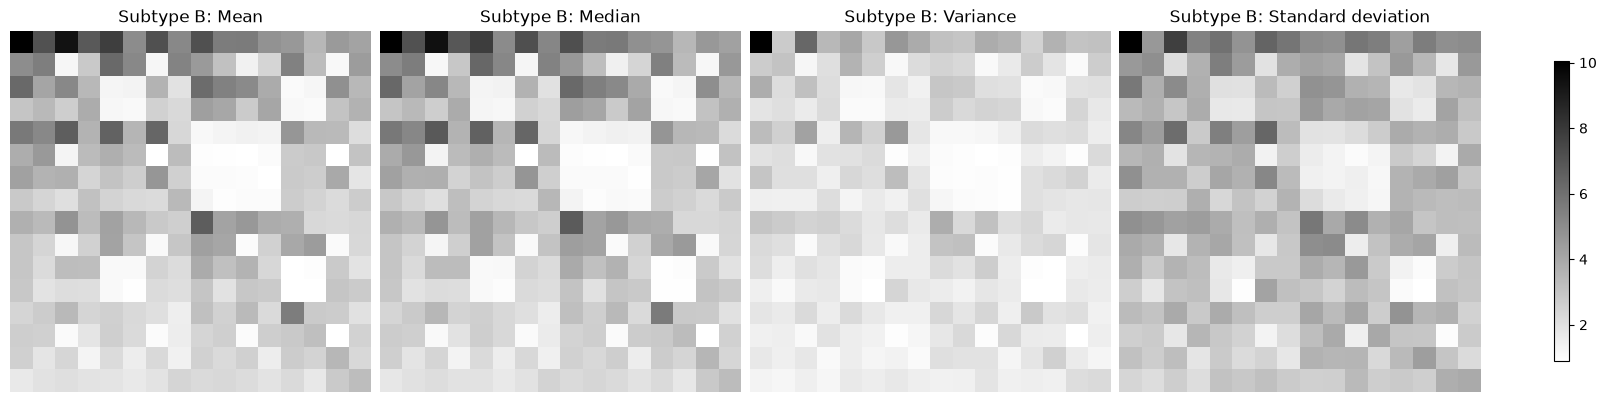

In [7]:
b_matrices = collection_statistics(subtype_b_collection)
plot_matrix_collection(
    b_matrices,
    "Subtype B"
)

<br>

### Subtype C

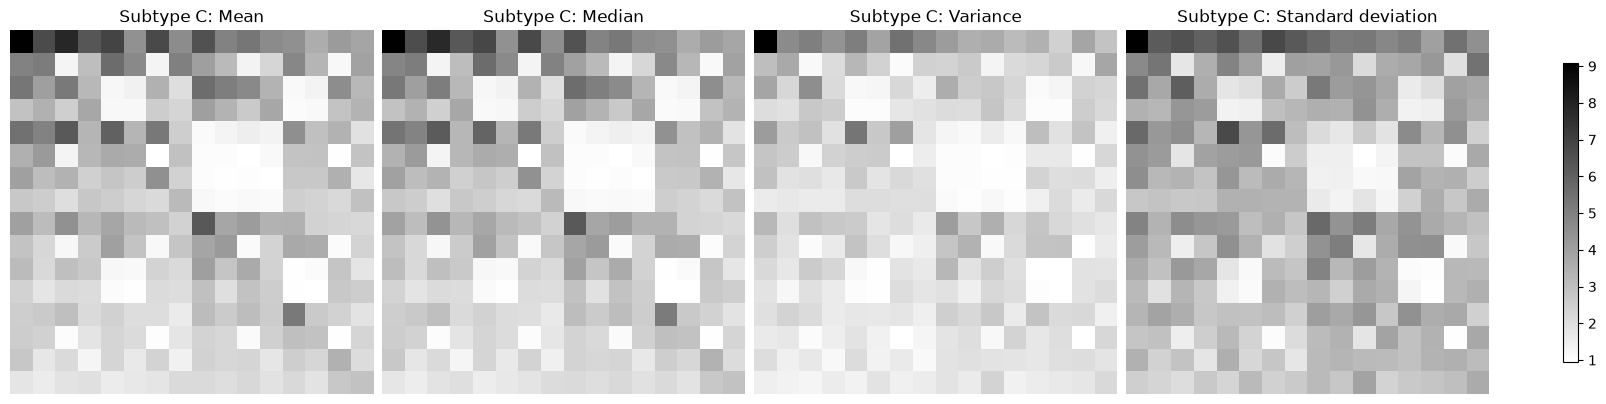

In [8]:
c_matrices = collection_statistics(subtype_c_collection)
plot_matrix_collection(
    c_matrices,
    "Subtype C"
)

<br>

# Comparision of the two populations

<br>

## Comparing Mean FCGR Representations
<br>
The difference between the mean FCGR matrices highlights positions where subtype B and subtype C show different frequency patterns. 
The difference is calculated as Subtype B minus Subtype C. Therefore, positive values indicate higher mean frequencies in the subtype B population, whereas negative values indicate higher mean frequencies in subtype C.

In [9]:
b_mean = b_matrices["Mean"]
c_mean = c_matrices["Mean"]

mean_difference = b_mean - c_mean

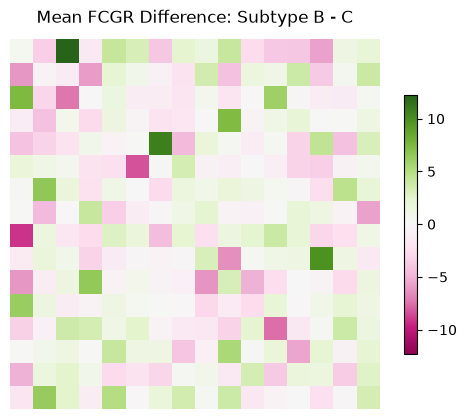

In [10]:
fig, ax, im = mean_difference.plot(
    cmap="PiYG",
    symmetric=True,
    colorbar=True,
    title="Mean FCGR Difference: Subtype B - C"
)

plt.show()

<br>

## Significant FCGR Features
<br>

Preparing stacked NumPy arrays for further analysis:


In [11]:
B_matrices = subtype_b_collection.stacked_matrix()
C_matrices = subtype_c_collection.stacked_matrix()

<br>

Pixel-wise statistical comparison of FCGR matrices using the Mann–Whitney U test with Bonferroni correction for multiple testing.

In [12]:
p_values = []

for i in range(subtype_b_collection.resolution):
    for j in range(subtype_b_collection.resolution):

        _, p = mannwhitneyu(
            B_matrices[:, i, j],
            C_matrices[:, i, j],
            alternative="two-sided"
        )

        p_values.append(p)

p_values_corrected = multipletests(
    p_values,
    method="bonferroni"
)[1]

p_value_matrix = Matrix(
    p_values_corrected.reshape(
        subtype_b_collection.resolution,
        subtype_b_collection.resolution
    )
)


<br>
Statistical significance (-log10 corrected p-values)

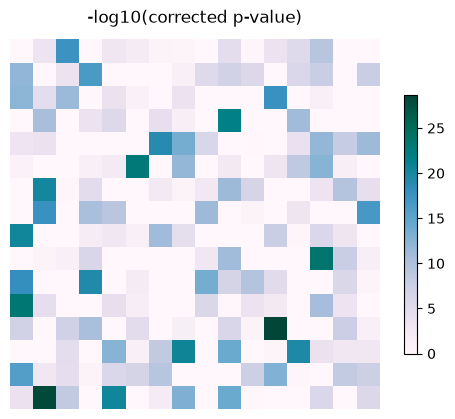

In [13]:
resolution = subtype_b_collection.resolution


p_value_matrix = Matrix(
    -np.log10(
        p_values_corrected.reshape(
            resolution,
            resolution
        )
    )
)

fig, ax, im = p_value_matrix.plot(
    cmap="PuBuGn",
    colorbar=True,
    title="-log10(corrected p-value)"
)

plt.show()

<br>

Significant FCGR positions

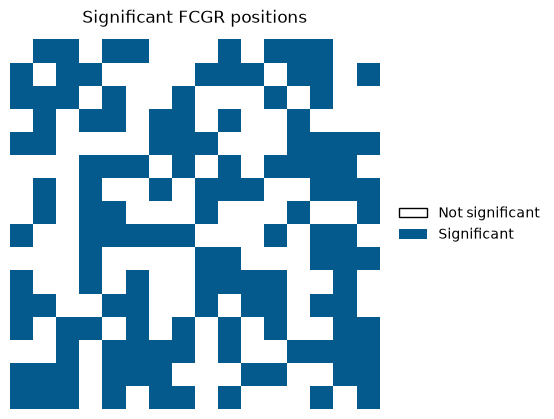

In [14]:
significant = p_values_corrected < 0.05


significant_matrix = Matrix(
    significant.astype(float).reshape(
        resolution,
        resolution
    )
)

fig, ax, im = significant_matrix.plot(
    cmap=ListedColormap(["white", blue]),
    colorbar=False,
    title="Significant FCGR positions"
)

legend_elements = [
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Not significant"
    ),
    Patch(
        facecolor=blue,
        label="Significant"
    )
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()

<br>

# Clustering

PCA projection of flattened FCGR representations, where each point represents one HIV-1 sample.

In [15]:
def plot_pca(
    subtype_b_collection,
    subtype_c_collection
):
    subtype_b_vectors = subtype_b_collection.feature_matrix()
    subtype_c_vectors = subtype_c_collection.feature_matrix()

    fcgr_vectors = np.concatenate(
        [
            subtype_b_vectors,
            subtype_c_vectors
        ]
    )

    subtypes = np.array(
        ["B"] * len(subtype_b_vectors) +
        ["C"] * len(subtype_c_vectors)
    )

    pca = PCA(
        n_components=2
    )

    fcgr_projection = pca.fit_transform(
        fcgr_vectors
    )

    plt.figure(figsize=(6, 5))
    

    for subtype in ["B", "C"]:
        mask = subtypes == subtype

        plt.scatter(
             fcgr_projection[mask, 0],
             fcgr_projection[mask, 1],
             label=f"Subtype {subtype}",
             color=pink if subtype == "B" else green)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA")
    plt.legend()

    plt.tight_layout()
    plt.show()

<br>

### Comparing resolutions

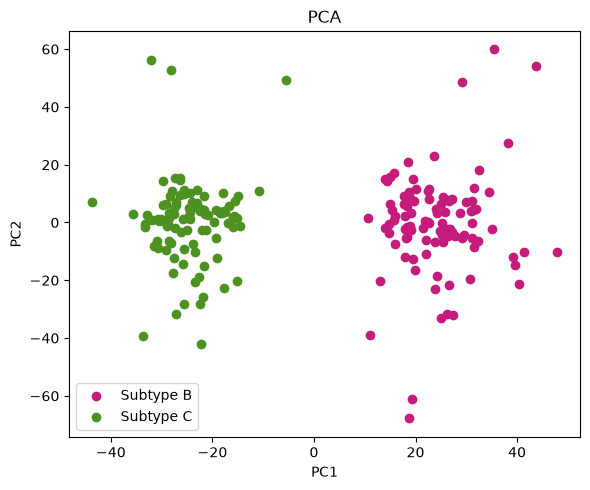

In [16]:
resolution=16

subtype_b_collection = FCGRCollection(
    subtype_b,
    symbols="DNA",
    resolution=resolution
)

subtype_c_collection = FCGRCollection(
    subtype_c,
    symbols="DNA",
    resolution=resolution
)

plot_pca(
    subtype_b_collection,
    subtype_c_collection
)

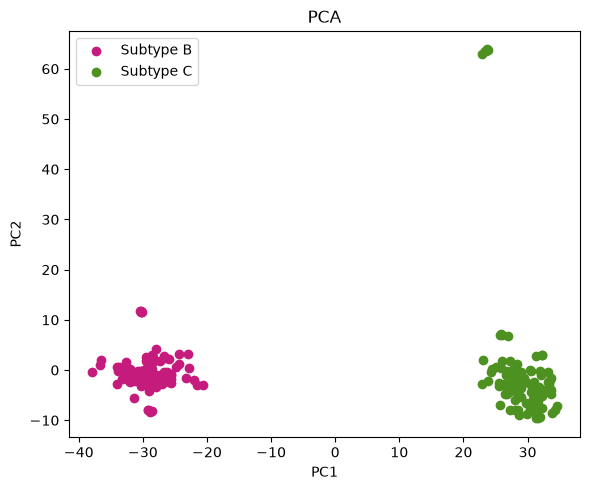

In [17]:
resolution=80

subtype_b_collection = FCGRCollection(
    subtype_b,
    symbols="DNA",
    resolution=resolution
)

subtype_c_collection = FCGRCollection(
    subtype_c,
    symbols="DNA",
    resolution=resolution
)

plot_pca(
    subtype_b_collection,
    subtype_c_collection
)

<br>

## Multi-Layer Perceptron
<br>

<br>

### Train-Test Split
<br>
Stratified train-test split preserving class distribution.

In [18]:
random_state=3
test_size=0.2

subtype_b_train_items, subtype_b_test_items = train_test_split(
    list(subtype_b.items()),
    test_size = test_size,
    random_state = random_state
)

subtype_c_train_items, subtype_c_test_items = train_test_split(
    list(subtype_c.items()),
    test_size = test_size,
    random_state = random_state
)

subtype_b_train = dict(subtype_b_train_items)
subtype_b_test = dict(subtype_b_test_items)

subtype_c_train = dict(subtype_c_train_items)
subtype_c_test = dict(subtype_c_test_items)

<br>

### FCGR Encoding

In [19]:
resolution=100
s="DNA"

subtype_b_train_collection = FCGRCollection(
    subtype_b_train,
    resolution=resolution,
    symbols=s
)

subtype_c_train_collection = FCGRCollection(
    subtype_c_train,
    resolution=resolution,
    symbols=s
)


subtype_c_test_collection = FCGRCollection(
    subtype_c_test,
    resolution=resolution,
    symbols=s
)

subtype_b_test_collection = FCGRCollection(
    subtype_b_test,
    resolution=resolution,
    symbols=s
)

<br>

### Preprocessing data
<br>

In [20]:
subtype_b_train_features = subtype_b_train_collection.feature_matrix()
subtype_c_train_features = subtype_c_train_collection.feature_matrix()

subtype_b_test_features = subtype_b_test_collection.feature_matrix()
subtype_c_test_features = subtype_c_test_collection.feature_matrix()


X_train = np.vstack([
    subtype_b_train_features,
    subtype_c_train_features
])

X_test = np.vstack([
    subtype_b_test_features,
    subtype_c_test_features
])


y_train = np.array(
    [0] * len(subtype_b_train_features)
    + [1] * len(subtype_c_train_features)
)

y_test = np.array(
    [0] * len(subtype_b_test_features)
    + [1] * len(subtype_c_test_features)
)

<br>

### Impact of Feature Scaling

In [21]:

def evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    hidden_layer_sizes=(20,),
    seed=3,
    scale=False
):

    if scale:
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        max_iter=1000,
        random_state=seed
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob)
    }

In [22]:
unscaled = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    scale=False
)

scaled = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    scale=True
)

In [23]:
print("Without scaling:", unscaled)
print("With scaling:", scaled)

Without scaling: {'accuracy': 1.0, 'auc': 1.0}
With scaling: {'accuracy': 1.0, 'auc': 1.0}


<br>

### Impact of Resolution

In [24]:
def evaluate_resolution(
    subtype_b_sequences,
    subtype_c_sequences,
    resolution,
    hidden_layer_sizes=(20,),
    seed=3
):


    s="DNA"
    subtype_b_collection = FCGRCollection(
        subtype_b_sequences,
        resolution=resolution,
        symbols=s
    )

    subtype_c_collection = FCGRCollection(
        subtype_c_sequences,
        resolution=resolution,
        symbols=s
    )

    X_subtype_b = np.array([
        fcgr.matrix.flatten()
        for fcgr in subtype_b_collection.fcgrs.values()
    ])

    X_subtype_c = np.array([
        fcgr.matrix.flatten()
        for fcgr in subtype_c_collection.fcgrs.values()
    ])

    X = np.vstack([
        X_subtype_b,
        X_subtype_c
    ])

    y = np.array(
        [0] * len(X_subtype_b)
        + [1] * len(X_subtype_c)
    )

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        max_iter=1000,
        random_state=seed
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    return scores

In [25]:
# Suppress convergence warning 
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)


resolutions = [5,20, 50, 100, 150,200]

results = {}

for res in resolutions:
    results[res] = evaluate_resolution(
        subtype_b_train,
        subtype_c_train,
        resolution=res
    )

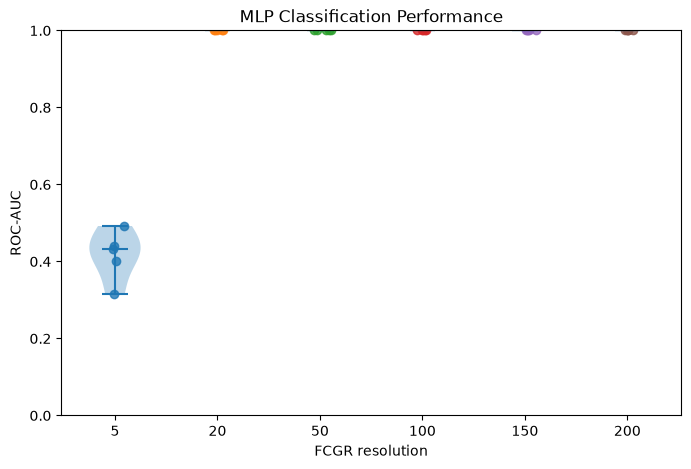

In [26]:
data = [
    results[5],
    results[20],
    results[50],
    results[100],
    results[150],
    results[200]
    
]

labels = [
    5,
    20,
    50,
    100,
    150,
    200
]


plt.figure(figsize=(8, 5))

parts = plt.violinplot(
    data,
    positions=np.arange(len(labels)) + 1,
    showmeans=False,
    showmedians=True
)


for i, values in enumerate(data):
    x = np.random.normal(
        i + 1,
        0.04,
        size=len(values)
    )
    
    plt.scatter(
        x,
        values,
        alpha=0.8
    )


plt.xticks(
    np.arange(len(labels)) + 1,
    labels
)

plt.xlabel("FCGR resolution")
plt.ylabel("ROC-AUC")

plt.ylim(
    0.0,
    1.0
)

plt.title(
    "MLP Classification Performance"
)


plt.show()